# Chemical Reaction Engineering III

## Python Introduction

In this introduction, you will learn how to solve engineering problems with python.
1. Do's and Don'ts for scientific programming.
1. How to solve algebraic equations using root finding solvers.
2. How to solve ordinary differential equations using integration solvers.
3. How to perform numerical optimization and fitting.
4. How to create scientific figures with our plotting library ICIW-Plots.


### Introduction to scientific programming

#### 1. What is Python and what are modules?

Python is an easy-to-use programming language with diverse application fields. Thus, it’s suitable for scientific, application-oriented simulation tasks. In this introduction the basic tools for solving scientific simulation problems are shown. This document is also designed to be useful for looking up parts of code later in time. 
Python itself provides functionalities which are not sufficient to solve scientific problems. For specific applications so-called packages or modules extend the functionalities. Focus here lies on the modules Numpy, Scipy and Matplotlib. Numpy is the basic module which provides ndimensional arrays. With Numpy, arrays can be created, edited and sorted. Further, algebraic calculations can be performed with Numpy. One-dimensional arrays can be interpreted as vectors and two-dimensional arrays as matrices. The module SciPy offers mathematical solvers to solve e.g. systems of non-linear equation or differential equations. Matplotlib provides the possibility to present and illustrate the simulation results in clear diagrams. All mentioned modules contain a lot more functionalities beyond the ones described here. Numpy for example provides comprehensive mathematical functions like Fourier transformations. The modules can be installed separately or by using a package manager like Anaconda. There are also more modules available that provide various functionalities like pandas and lmfit.



**NOTE:** Before running the code, make sure all modules (see below) are installed and accessible in your path. Our plotting style is included in the module `ICIW-Plots`. You can install it like every other module. Type:

`pip install ICIW-Plots`

The documentation can be found here: https://pypi.org/project/ICIW-Plots/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ICIWstyle')
plt.rcParams['font.size'] = 12
from scipy.integrate import solve_ivp
import pandas as pd
from lmfit import Parameters,Minimizer,report_fit

#### 2. Coding structure

It is important that the written code follows a logical and visible structure. The following structure is recommended.
1. Import of all required modules
2. Definition of parameters
3. Definition of functions
4. Configuration and call of solvers
5. Graphical representation of simulation results

Note that the execution of the program is performed from top to bottom. Furthermore, the syntax uses indentation for nested expressions. To prevent mistakes and confusions the following points need to be addressed.
- Don’t use the same variable name twice for different purposes!
- Use meaningful variable names and do not chose too short ones!
- Comment comprehensively!
- Be aware of correct indentation for nesting of expressions!


The following example shows a well-structured code to calculate and graphically display a parabolic function 

$$𝑦(𝑥) = 𝑎𝑥^2 − 𝑏$$ 

with x-values from -3 to 3.


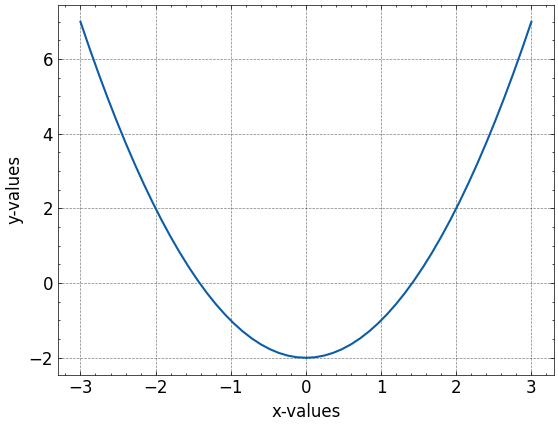

In [259]:
## Definition of parameters
a = 1
b = 2

## Definition of functions
def parabolic_function(x): 
    result = a*x**2 - b 
    return result 

## Configuration and call of solvers
x_vec = np.linspace(-3,3,51) # creates x-array from -3 to 3 with 51 steps
y = parabolic_function(x_vec) # calculation of y-values by calling the function 

## Graphical representation of simulation results
fig, ax = plt.subplots() # create blank figure
ax.plot(x_vec,y) # plot values
ax.set(ylabel='y-values') # caption of y-axis
ax.set(xlabel='x-values') # caption of x-axis
plt.show() # show figure

### Solving algebraic equations

#### Example 1

Water with density of $\rho=1000 \, \mathrm{kg/m^3}$ and viscosity of $\eta = 0.5 \, \mathrm{mPas}$ flows through a pipe with diameter $d_i = 25.4 \, \mathrm{mm}$. At which volumetric flow rate $\dot{V}$ does the Reynolds number $Re$ reach a value of 2300?

$$ v = \frac{4\dot{V}}{\pi d_i^2}$$
$$ Re = \frac{v \rho d_i}{\eta}$$


For the numerical solution, we set up a equation that needs to be solved, in the form of $0 = f(x)$. In our case we want the Re number to be 2300.

$$ 0 = Re - 2300$$


Volumetric flow rate: 0.0229 m^3/s


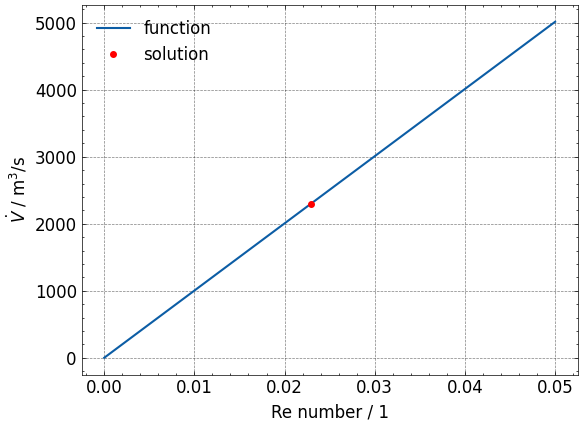

In [260]:
from scipy.optimize import root

rho = 1000 # density of water in kg/m^3
eta = 0.5e-3 # dynamic viscosity of water in Pa*s
d_i = 25.4e-3 # inner diameter of the pipe in m

def velocity(Vdot):
    """Calculate the velocity of water in the pipe.
    Vdot: volumetric flow rate in m^3/s
    """
    A = np.pi * (d_i / 2)**2 # cross-sectional area of the pipe
    v = Vdot / (rho * A) # velocity in m/s
    return v

def reynolds_number(Vdot):
    """Calculate the Reynolds number.
    Vdot: volumetric flow rate in m^3/s"""
    v = velocity(Vdot) # velocity in m/s
    Re = (rho * v * d_i) / eta # Reynolds number
    return Re

def residual_function(Vdot):
    '''Calculates the residual of the equation to be solved
    Vdot: volumetric flow rate in m^3/s
    Residual function for the equation Re = 2300.'''
    Re = reynolds_number(Vdot) # calculate Reynolds number
    residual = 2300 - Re
    return residual 

Vdot_guess = 0.01 # initial guess for volumetric flow rate in m^3/s
sol = root(residual_function, Vdot_guess) # solve the equation
Vdot_solution = sol.x[0] # extract the solution

print(f'Volumetric flow rate: {Vdot_solution:.4f} m^3/s')

Vdot_arr = np.linspace(0, 0.05, 100) # create an array of volumetric flow rates
Re_arr = reynolds_number(Vdot_arr) # calculate the corresponding Reynolds numbers
fig, ax = plt.subplots()
ax.plot(Vdot_arr,Re_arr,label='function')
ax.plot(Vdot_solution, 2300, 'ro',label='solution')
ax.legend()
ax.set(ylabel='$\dot{V}$ / $\mathrm{m^3}$/$\mathrm{s}$')
ax.set(xlabel='Re number / 1')
plt.show()

#### Task 1
Find the x values of the parabolic function from above, where y equals 2. Try different guesses and investigate the result.

In [261]:

def residual_parabolic(x):
    y = parabolic_function(x) # calculate y-values
    residual = y - 2 # residual function for the equation y = 2
    return residual

x_guess = 0 # initial guess for x
sol = root(residual_parabolic, x_guess)
x_solution = sol.x[0]
print(f'Solution of the equation: x = {x_solution:.1f}')

## Iteration of different guesses
print('\nIterating over different guesses:')

for x_guess in [-3, -2, -1, 0, 1, 2, 3]:
    sol = root(residual_parabolic, x_guess)
    x_solution = sol.x[0]
    print(f'Solution of the equation: x = {x_solution:.1f} for x_guess = {x_guess}')

Solution of the equation: x = 2.0

Iterating over different guesses:
Solution of the equation: x = -2.0 for x_guess = -3
Solution of the equation: x = -2.0 for x_guess = -2
Solution of the equation: x = -2.0 for x_guess = -1
Solution of the equation: x = 2.0 for x_guess = 0
Solution of the equation: x = 2.0 for x_guess = 1
Solution of the equation: x = 2.0 for x_guess = 2
Solution of the equation: x = 2.0 for x_guess = 3


### Solving ordinary differential equations

#### Example 2
Water has a specific heat capacity of $4200 \, \mathrm{J/kgK}$. The water enters the pipe with a temperature of 90 °C. The pipe is surrounded by an environment at 20 °C. The heat transfer coefficient $k_wa_w$ is determined to $3000 \, \mathrm{W/Km}$. How does the axial temperature profile look like?

The heat loss across the wall can be calculated with
$$\dot{q}_\mathrm{loss} = k_wa_w (T_\mathrm{water} - T_\mathrm{env})$$

The heat balance is derived to
$$ \dot{V} \rho c_p \frac{dT_\mathrm{water}}{dx} = - \dot{q}_\mathrm{loss}$$

With the inlet condition: $T_\mathrm{water}(x=0) = 90 \mathrm{°C}$

Solution:
To solve the ordinary differential equation we need to rearange the equation to the form of $\frac{dy}{dx} = f(x,y)$. In our case the equations changes to: 
$$ \frac{dT_\mathrm{water}}{dx} =  \frac{- \dot{q}_\mathrm{loss}} {\dot{V} \rho c_p}$$
Which means we need to implement a function that gets the axial position `x` and the water temperature `T_water` as inputs and returns the gradient of the temperature in axial direction `dT_waterdx`. 

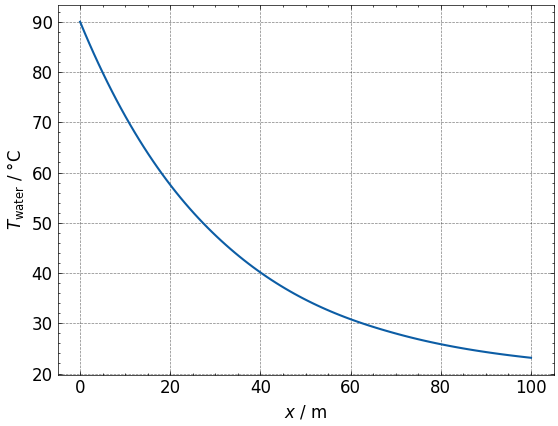

In [262]:
c_p = 4200 # specific heat capacity of water in J/(kg*K)
k_wa_w = 3000 # heat transfer coefficient in W/(m*K)
T_env = 20+273.15 # ambient temperature in K

def heat_loss(T_water):
    """Calculate the heat loss from the water to the environment.
    T_water: temperature of the water in K
    """
    Q_loss = k_wa_w * (T_water - T_env) # heat loss in W
    return Q_loss

def heat_balance(x,T_water):
    """Calculate the heat balance for the water in the pipe.
    x: distance along the pipe in m
    T_water: temperature of the water in K
    """
    q_loss = heat_loss(T_water) # calculate heat loss
    dTdx = -q_loss / (c_p * rho * Vdot_solution) # heat balance equation
    return dTdx

T_water_inlet = np.array([90+273.15]) # inlet temperature in K
x_inlet = 0 # inlet position in m
x_outlet = 100 # outlet position in m
x = np.linspace(x_inlet, x_outlet, 100) # create an array of positions along the pipe

sol = solve_ivp(heat_balance, (x[0],x[-1]), T_water_inlet, t_eval=x) # solve the ODE

T_water_solution = sol.y[0] # extract the solution

fig, ax = plt.subplots()
ax.plot(x, T_water_solution - 273.15)
ax.set(ylabel='$T_\mathrm{water}$ / °C')
ax.set(xlabel='$x$ / m')
plt.show()

#### Task 2

It is often necessary to solve coupled differential equations. A typical case is the calculation of concentration profiles over time. A reaction network is given with: $k_1 = 0.001 \, \mathrm{s}^{-1}$,  $k_2 = 0.002\,\mathrm{s}^{-1}$, $c_{\mathrm{A},0} = 2 \,\mathrm{mol m^{-3}}$ , $c_{\mathrm{B},0} = 0$, $c_{\mathrm{C},0} = 0.01 \, \mathrm{mol m^{-3}}$ and 

$$ \text{A} \xrightarrow[]{k_1} \text{B} \xrightarrow[]{k_2} 2 \, \text{C}$$

The first reaction is 2nd order for component A and the second reaction is first order for concentration of B and reciprocal to the concentration of C (inhibition).

 a) Calculate the solution for this initial value problem.

In [263]:
def reaction(t, f):
    "function to describe the reaction progress over time"
    # f is a vector containing concentrations of components (c_i) in mol/m^3
    c_A = f[0]
    c_B = f[1]
    c_C = f[2]

    # declaration of rate constants
    k_1 = 0.01 # rate constant 1 1/s
    k_2 = 0.001 # rate constant 1 1/s

    # differential equations
    dc_Adt = -k_1*c_A**2
    dc_Bdt = k_1*c_A**2-k_2*c_B/c_C
    dc_Cdt = 2*k_2*c_B/c_C

    dfdt = np.empty_like(f)
    dfdt[0] = dc_Adt
    dfdt[1] = dc_Bdt
    dfdt[2] = dc_Cdt
    return dfdt

# INITIALS
f_init = np.array([2, 0, 0.01])

# SOLUTION
tspan = np.array([0, 1000])
teval = np.linspace(0,tspan[1],2001)
sol = solve_ivp(reaction, tspan, f_init, method='BDF', t_eval =teval)

In [264]:
sol #gives all information connected with the execution of the function

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.000e-01 ...  9.995e+02  1.000e+03]
        y: [[ 2.000e+00  1.980e+00 ...  9.536e-02  9.532e-02]
            [ 0.000e+00  1.935e-02 ...  8.960e-01  8.958e-01]
            [ 1.000e-02  1.091e-02 ...  2.027e+00  2.028e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 135
     njev: 3
      nlu: 18

 b) Calculate the following extrema

*   maximum in component B (value, index in array and time).
*   highest slope for all components (value and time).

In [265]:
maxB = np.max(sol.y[1,:]) #finding maximum in arra y
index_maxB = np.argmax(sol.y[1,:]) # finding array element
print('Maximum value of component B is: ',maxB)
print('At index: ', index_maxB)
print('This corresponds to a time: ', sol.t[index_maxB])

index_maxdAdt = np.argmax(np.diff(sol.y[0,:]))
index_mindAdt = np.argmin(np.diff(sol.y[0,:]))
index_maxdBdt = np.argmax(np.diff(sol.y[1,:]))
index_mindBdt = np.argmin(np.diff(sol.y[1,:]))
index_maxdCdt = np.argmax(np.diff(sol.y[2,:]))
index_mindCdt = np.argmin(np.diff(sol.y[2,:]))


Maximum value of component B is:  1.17505048062859
At index:  475
This corresponds to a time:  237.5


 c) Plot the obtained results

Plot the obtained results including the extrema

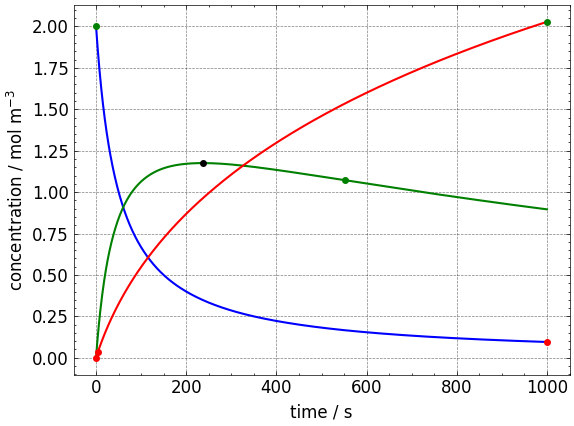

In [266]:
# POSTPROCESSING & PLOTTING
fig1, ax = plt.subplots()
ax.set(xlabel='time / s', ylabel='concentration / mol m$^{-3}$')
ax.plot(sol.t, sol.y[0,:], 'b-')
ax.plot(sol.t, sol.y[1,:], 'g-')
ax.plot(sol.t, sol.y[2,:], 'r-')
ax.plot(sol.t[index_maxB], maxB, 'ko')
#minima
ax.plot(sol.t[index_mindAdt], sol.y[0,index_mindAdt], 'go')
ax.plot(sol.t[index_mindBdt], sol.y[1,index_mindBdt], 'go')
ax.plot(sol.t[index_mindCdt], sol.y[2,index_mindCdt], 'go')
# maxima
ax.plot(sol.t[index_maxdAdt], sol.y[0,index_maxdAdt], 'ro')
ax.plot(sol.t[index_maxdBdt], sol.y[1,index_maxdBdt], 'ro')
ax.plot(sol.t[index_maxdCdt], sol.y[2,index_maxdCdt], 'ro')

plt.show()

### Parameter fitting

In many situations, not all parameters are defined when modelling a real system. In our example, we assume that the heat transfer coefficient is unknown and needs to be determined using a parameter fit. For the parameter fit we need to formulate an objective function that is to be minimized by the optimization algorithm.

In our case, we want to minimize the difference between experimental temperature profile $T_\mathrm{experimental}$ and the simulated tempeature profile from the model with the heat transfer coefficient as variable $T_\mathrm{model}(k_wa_w)$. The boundaries of the variable are set to positive values $k_wa_w \in [0, \inf)$. Mathematically, the optimization problem is formulated as follows.

$$ \mathrm{argmin} \, (T_\mathrm{experimental} - T_\mathrm{model}(k_wa_w)) $$
$$ \mathrm{subject \, to}: \, k_wa_w \in [0, \inf) $$

Let's generate a data set which contains pseudo experimental temperature data. Therefore, we add noise to the simulated temperature profile and store the data in a pandas DataFrame `pd.DataFrame`. Data frames are suitable for storage of large data sets that are shaped like an Excel data sheet in 2D. You can define column names which are easy to handle. The advantage compared to numpy ND-arrays is that you do not need to know the column number to access your data, but you directly call the column name instead. To generate numpy ND-arrays from pandas DataFrames you just call the `to_numpy()` function, as shown below. For single columns you call `.values` to convert the column data into a 1D array. Further, `pd.DataFrames` can be stored easily into csv files.

In [267]:
## Add noise to the water temperature as experimental data 
T_water_experimental = T_water_solution + np.random.normal(0, 1, T_water_solution.shape) # add noise

## Create pandas data frame and store the experimental data in a CSV file
df_water = pd.DataFrame({'x': x, 'T_water': T_water_experimental})
df_water.to_csv('water_pipe.csv')

Check the data types

In [268]:
print('Data frame:\n',df_water)

Data frame:
              x     T_water
0     0.000000  364.944459
1     1.010101  361.227135
2     2.020202  358.880172
3     3.030303  356.771610
4     4.040404  354.308812
..         ...         ...
95   95.959596  295.308091
96   96.969697  296.475053
97   97.979798  297.403826
98   98.989899  295.892240
99  100.000000  298.049919

[100 rows x 2 columns]


In [269]:
print(type(df_water))

<class 'pandas.core.frame.DataFrame'>


In [270]:
print(type(df_water.to_numpy() )) 

<class 'numpy.ndarray'>


In [271]:
print(type(df_water['T_water']))

<class 'pandas.core.series.Series'>


In [272]:
print(type(df_water['T_water'].values))

<class 'numpy.ndarray'>


Let's read the generated experimental data from the csv file and visualize it.

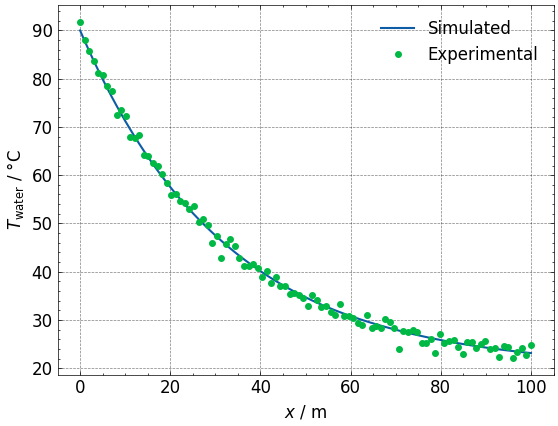

In [273]:
## test if the stored data is correctly read
data_water_pipe = pd.read_csv('water_pipe.csv') # read the CSV file
x = data_water_pipe['x'].values # extract x values
T_water_experimental = data_water_pipe['T_water'].values # extract T_water values

fig, ax = plt.subplots()
ax.plot(x, T_water_solution - 273.15, label='Simulated')
ax.plot(x, T_water_experimental - 273.15, 'o', label='Experimental')
ax.set(ylabel='$T_\mathrm{water}$ / °C')
ax.set(xlabel='$x$ / m')
ax.legend()
plt.show()

First, we create a lmfit.Parameters object to store all parameter values. For our variable `k_wa_w`, which we want to determine, we set the argument `vary` to `True` and define the boundaries for the solver (minimum value: 0, maximum value: infinity). Next, the functions to calculate the heat loss and the energy balance need to be adjusted to work for variable parameter values. Therefore, we add parameters as arguments. 

In [274]:
parameters = Parameters()
parameters.add('k_wa_w', value=3000, min=0, max=10000, vary=True) # heat transfer coefficient in W/(m*K)
parameters.add('T_environment', value=20+273.15, vary=False) # in K
parameters.add('volumetric_flowrate', value=Vdot_solution, vary=False) # in m^3/s
parameters.add('specific_heat_capacity', value=c_p, vary=False) # in J/(kg*K)
parameters.add('density', value=rho, vary=False) # in kg/m^3
parameters.add('inner_diameter', value=d_i, vary=False) # in m
parameters.add('inlet_temperature', value=90+273.15, vary=False) # in K
parameters.add('inlet_position', value=0, vary=False) # in m
parameters.add('length', value=100, vary=False) # in m 
parameters.add('number_of_discretizations', value=100, vary=False) 


def heat_loss(T_water, k_wa_w, T_env):
    """Calculate the heat loss from the water to the environment.
    T_water: temperature of the water in K
    """
    q_loss = k_wa_w * (T_water - T_env) # heat loss in W
    return q_loss

def heat_balance(x,T_water,parameters):
    """Calculate the heat balance for the water in the pipe.
    x: distance along the pipe in m
    T_water: temperature of the water in K
    parameters: lmfit parameter object 
    """
    ## Extract parameters from the lmfit parameter object
    k_wa_w = parameters['k_wa_w'].value
    c_p = parameters['specific_heat_capacity'].value
    rho = parameters['density'].value
    Vdot = parameters['volumetric_flowrate'].value
    T_env = parameters['T_environment'].value
    ## Heat loss
    q_loss = heat_loss(T_water,k_wa_w=k_wa_w, T_env=T_env) # calculate heat loss
    ## Heat balance equation
    dTdx = -q_loss / (c_p * rho * Vdot)
    return dTdx    

Next, we create a function that contains the solution of our model and a function that contains the objective function.

In [275]:
def model(parameters):
    '''Calculates the temperature profile of the water in the pipe according to the given parameter set.
    parameters: lmfit parameter object'''
    T_water_inlet = parameters['inlet_temperature'].value # inlet temperature in K
    x_inlet = parameters['inlet_position'].value # inlet position in m
    x_outlet = x_inlet + parameters['length'].value # outlet position in m
    N_steps = parameters['number_of_discretizations'].value # number of steps in the pipe
    x = np.linspace(x_inlet, x_outlet, N_steps) # create an array of positions along the pipe

    sol = solve_ivp(heat_balance, (x_inlet,x_outlet), np.array([T_water_inlet,]), t_eval=x,args=(parameters,))

    ## Create pandas data frame with results
    results = pd.DataFrame({'x': sol.t, 'T_water': sol.y[0]})

    return results

def objective_function(parameters):
    '''Objective function for the lmfit minimizer.
    parameters: lmfit parameter object'''
    
    results = model(parameters) # calculate the model results
    T_water_model = results['T_water'].values # extract the model results

    ## Calculate the residuals between the experimental and model data
    residuals = T_water_experimental - T_water_model

    return residuals

In [276]:
minimizer = Minimizer(objective_function, parameters)
result = minimizer.minimize(method='leastsq') # use the least squares method

report_fit(result) # print the fit report

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 100
    # variables        = 1
    chi-square         = 123.016255
    reduced chi-square = 1.24258843
    Akaike info crit   = 22.7146315
    Bayesian info crit = 25.3198017
[[Variables]]
    k_wa_w:                     3015.30086 +/- 17.5440882 (0.58%) (init = 3000)
    T_environment:              293.15 (fixed)
    volumetric_flowrate:        0.02294148 (fixed)
    specific_heat_capacity:     4200 (fixed)
    density:                    1000 (fixed)
    inner_diameter:             0.0254 (fixed)
    inlet_temperature:          363.15 (fixed)
    inlet_position:             0 (fixed)
    length:                     100 (fixed)
    number_of_discretizations:  100 (fixed)


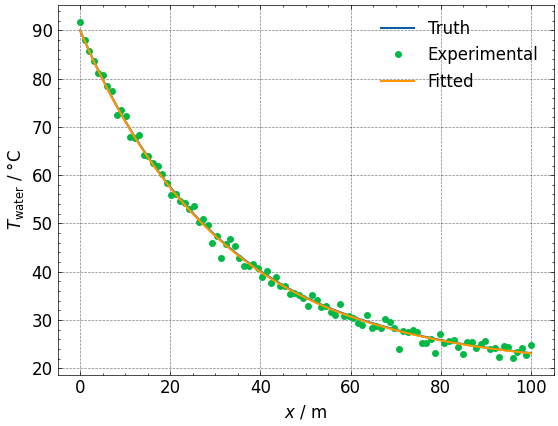

In [277]:
## Compare the fit with the original data
fig, ax = plt.subplots()
ax.plot(x, T_water_solution - 273.15, label='Truth')
ax.plot(x, T_water_experimental - 273.15, 'o', label='Experimental')
ax.plot(x, model(result.params)['T_water'] - 273.15, label='Fitted')
ax.set(ylabel='$T_\mathrm{water}$ / °C')
ax.set(xlabel='$x$ / m')
ax.legend()
plt.show()

#### Task 3

Create pseudo-experimental data for the parabolic function. Try to find the parameter values for a and b.

In [278]:
parameters = Parameters()
parameters.add('a',value = 1, min=-np.inf, max=np.inf, vary=True)
parameters.add('b',value = 2, min=-np.inf, max=np.inf, vary=True)

y_exp = y + np.random.normal(0, 1, y.shape) # add noise to the y-values

def parabolic_function(x, parameters):
    '''Parabolic function with parameters a and b'''
    a = parameters['a'].value
    b = parameters['b'].value
    result = a*x**2 - b 
    return result

def objective_function_parabolic(parameters):
    '''Objective function for the lmfit minimizer.
    parameters: lmfit parameter object'''
    
    y_model = parabolic_function(x_vec, parameters) # calculate the model results
    residuals = y_exp - y_model # calculate the residuals between the experimental and model data

    return residuals

minimizer = Minimizer(objective_function_parabolic, parameters)
result = minimizer.minimize(method='leastsq') # use the least squares method

report_fit(result) # print the fit report




[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 51
    # variables        = 2
    chi-square         = 49.4291213
    reduced chi-square = 1.00875758
    Akaike info crit   = 2.40441998
    Bayesian info crit = 6.26807124
[[Variables]]
    a:  1.06669087 +/- 0.05042657 (4.73%) (init = 1)
    b:  2.00599618 +/- 0.21102742 (10.52%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = +0.7455


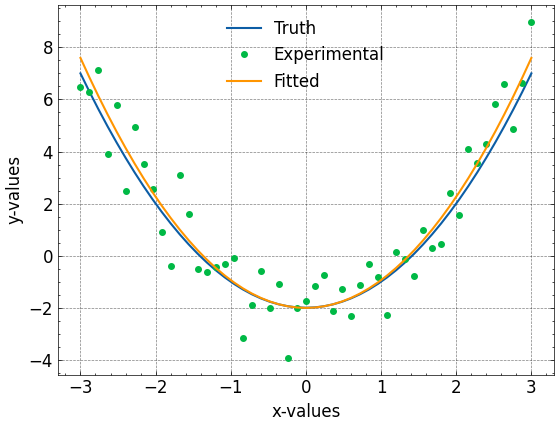

In [279]:
## Compare the fit with the original data
fig, ax = plt.subplots()
ax.plot(x_vec, y, label='Truth')
ax.plot(x_vec, y_exp, 'o', label='Experimental')
ax.plot(x_vec, parabolic_function(x_vec, result.params), label='Fitted')
ax.set(ylabel='y-values')
ax.set(xlabel='x-values')
ax.legend()
plt.show()

Play around with the parameter values and the amount of noise. What can you conclude about their influence on the confindence interval and the correlations